In [2]:
# Ensure the project root is on PYTHONPATH when running from notebooks/
from pathlib import Path
import sys
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))



# 03 - Proposed OFO-NN (faster convergence)

In [5]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

from hybrid_acdc.cli.main import cmd_iterate
from hybrid_acdc.utils.io import load_json
import argparse

cfg_path = '../config/system.yaml'
pid_ref_path = '../results/pid_ref/pid_ref.json'
out_dir = Path('../results/ofo_nn'); out_dir.mkdir(parents=True, exist_ok=True)

args = argparse.Namespace(config=cfg_path, pid_ref=pid_ref_path, controller='ofo_nn', out=str(out_dir),
                          iters=30, step_size=0.08, perturb=0.2, verbose=True)
cmd_iterate(args)

hist_nn = load_json(out_dir/'iterate_history.json')


[ofo_nn] iter 001/30: mean_cost=8751300422.1972  theta(vdc_kp)=30.000  theta(vdc_ki)=5000.0  alpha=0.552  err_to_ref=0.9205
[ofo_nn] iter 002/30: mean_cost=8751300419.4948  theta(vdc_kp)=30.000  theta(vdc_ki)=5000.0  alpha=0.553  err_to_ref=0.9205
[ofo_nn] iter 003/30: mean_cost=8698704554.2874  theta(vdc_kp)=30.000  theta(vdc_ki)=4993.6  alpha=0.552  err_to_ref=0.9206
[ofo_nn] iter 004/30: mean_cost=8751300447.9224  theta(vdc_kp)=30.000  theta(vdc_ki)=5000.0  alpha=0.550  err_to_ref=0.9205
[ofo_nn] iter 005/30: mean_cost=8698704627.1994  theta(vdc_kp)=30.000  theta(vdc_ki)=4993.6  alpha=0.548  err_to_ref=0.9206
[ofo_nn] iter 006/30: mean_cost=8656797090.8734  theta(vdc_kp)=30.000  theta(vdc_ki)=4987.2  alpha=0.550  err_to_ref=0.9207
[ofo_nn] iter 007/30: mean_cost=8698704627.1994  theta(vdc_kp)=30.000  theta(vdc_ki)=4993.6  alpha=0.548  err_to_ref=0.9206
[ofo_nn] iter 008/30: mean_cost=8751300447.9224  theta(vdc_kp)=30.000  theta(vdc_ki)=5000.0  alpha=0.550  err_to_ref=0.9205
[ofo_nn]

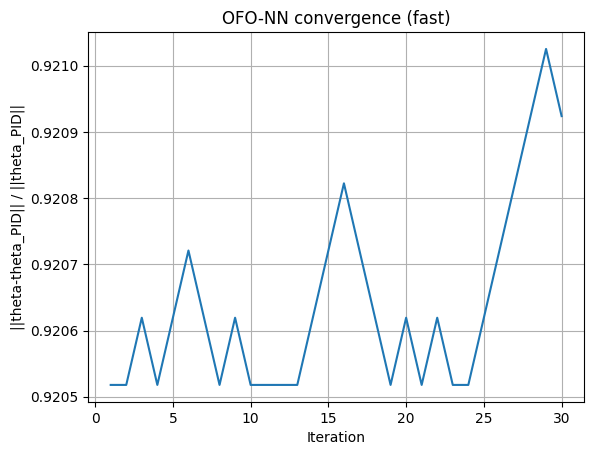

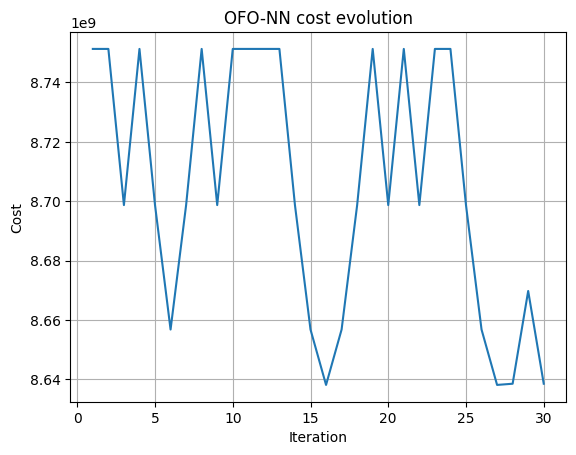

In [6]:
import matplotlib.pyplot as plt
h = hist_nn['history']
its = [r['iter'] for r in h]
errs = [r['err_to_pid_ref'] for r in h]
J = [r['mean_cost'] for r in h]

plt.figure(); plt.plot(its, errs)
plt.xlabel('Iteration'); plt.ylabel('||theta-theta_PID|| / ||theta_PID||')
plt.grid(True); plt.title('OFO-NN convergence (fast)')
plt.show()

plt.figure(); plt.plot(its, J)
plt.xlabel('Iteration'); plt.ylabel('Cost')
plt.grid(True); plt.title('OFO-NN cost evolution')
plt.show()


In [3]:
from pathlib import Path
from hybrid_acdc.utils.io import load_json

out_dir = Path('../results/ofo_nn')
hist_nn = load_json(out_dir / 'iterate_history.json')


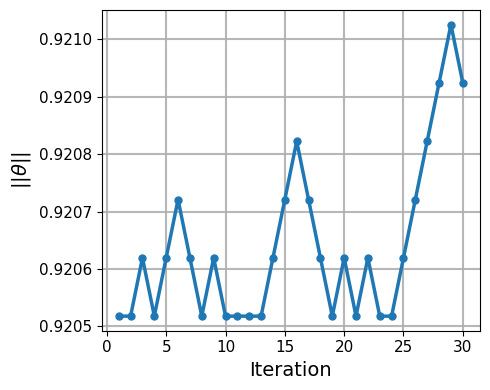

In [18]:
import matplotlib.pyplot as plt

h = hist_nn['history']
its  = [r['iter'] for r in h]
errs = [r['err_to_pid_ref'] for r in h]

plt.figure(figsize=(5, 4))  # Good for IEEE / Elsevier one-column

plt.plot(
    its,
    errs,
    linewidth=2.5,      # Thicker convergence curve
    marker='o',
    markersize=5
)

plt.xlabel('Iteration', fontsize=14)
plt.ylabel(r'$||\theta||$', fontsize=14)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, which='both', linestyle='-', linewidth=1.5, alpha=0.9)

plt.tight_layout()
plt.show()


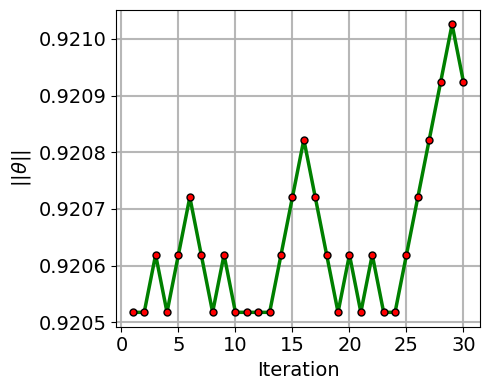

In [26]:
import matplotlib.pyplot as plt

h = hist_nn['history']
its  = [r['iter'] for r in h]
errs = [r['err_to_pid_ref'] for r in h]

plt.figure(figsize=(5, 4))  # 
plt.plot(
    its,
    errs,
    linewidth=2.5,
    marker='o',
    markersize=5,
    color='green',                 # line color
    markerfacecolor='red',       # marker fill
    markeredgecolor='black'      # marker edge (very clean in print)
)

plt.xlabel('Iteration', fontsize=14)
plt.ylabel(r'$||\theta||$', fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(True, which='both', linestyle='-', linewidth=1.5, alpha=0.9)

plt.tight_layout()

# ---- Save as vector PDF (same directory) ----
plt.savefig(
    "Fig_OFO_NN_Convergence.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


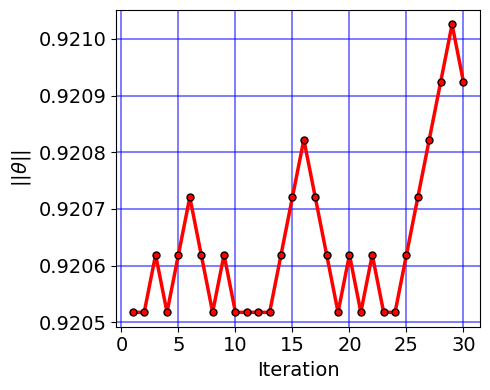

In [25]:
import matplotlib.pyplot as plt

h = hist_nn['history']
its  = [r['iter'] for r in h]
errs = [r['err_to_pid_ref'] for r in h]

plt.figure(figsize=(5, 4))  # IEEE / Elsevier one-column

plt.plot(
    its,
    errs,
    linewidth=2.5,
    marker='o',
    markersize=5,
    color='red',                 # line color
    markerfacecolor='red',       # marker fill
    markeredgecolor='black'      # marker edge (print-safe)
)

plt.xlabel('Iteration', fontsize=14)
plt.ylabel(r'$||\theta||$', fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# ---- Colored grid (subtle, journal-safe) ----
plt.grid(
    True,
    which='both',
    linestyle='-',
    linewidth=1.2,
    color='blue',
    alpha=0.6
)

plt.tight_layout()

# ---- Save as vector PDF (same directory) ----
plt.savefig(
    "Fig_OFO_NN_Convergence.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


In [ ]:
#### END 

In [5]:
from pathlib import Path
import sys

ROOT = Path('..').resolve()          # project root (same as before)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


In [6]:
from pathlib import Path
from hybrid_acdc.utils.io import load_json

out_dir_ofo = Path('../results/ofo')   # <-- OFO results folder
hist = load_json(out_dir_ofo / 'iterate_history.json')


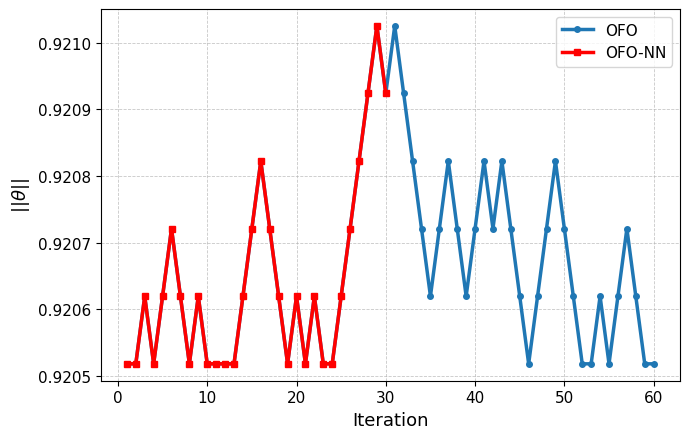

In [7]:
import matplotlib.pyplot as plt

# -------- OFO --------
h_ofo = hist['history']
its_ofo  = [r['iter'] for r in h_ofo]
errs_ofo = [r['err_to_pid_ref'] for r in h_ofo]

# -------- OFO-NN --------
h_nn = hist_nn['history']
its_nn  = [r['iter'] for r in h_nn]
errs_nn = [r['err_to_pid_ref'] for r in h_nn]

# -------- Plot --------
plt.figure(figsize=(7, 4.5))  # Single-column journal size

# OFO (default color)
plt.plot(
    its_ofo,
    errs_ofo,
    linewidth=2.5,
    marker='o',
    markersize=4,
    label='OFO'
)

# OFO-NN (red)
plt.plot(
    its_nn,
    errs_nn,
    linewidth=2.5,
    marker='s',
    markersize=4,
    color='red',
    label='OFO-NN'
)

plt.xlabel('Iteration', fontsize=13)
plt.ylabel(r'$||\theta||$', fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.7)

plt.legend(fontsize=11, frameon=True)
plt.tight_layout()
plt.show()
